# IMDB Movie Database Analaysis

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

In [2]:
df = pd.read_csv('data/clean_imdb.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title_id        100 non-null    str    
 1   original_title  100 non-null    str    
 2   genre           100 non-null    str    
 3   duration        100 non-null    float64
 4   country         100 non-null    str    
 5   content_rating  100 non-null    str    
 6   director        100 non-null    str    
 7   income          100 non-null    int64  
 8   votes           100 non-null    int64  
 9   score           100 non-null    float64
 10  year            100 non-null    int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 8.7 KB


In [3]:
df.describe()

,duration,income,votes,score,year
count,100.000000,1.000000e+02,1.000000e+02,100.000000,100.000000
mean,135.000000,2.991543e+08,8.297713e+05,8.236000,1989.850000
std,30.399445,4.360137e+08,4.829340e+05,0.449134,20.576723
min,81.000000,7.344600e+04,1.957890e+05,7.400000,1937.000000
25%,115.000000,2.374174e+07,3.890690e+05,7.900000,1976.750000
50%,129.500000,1.093370e+08,7.515385e+05,8.300000,1995.000000
75%,150.250000,4.052080e+08,1.102243e+06,8.600000,2004.250000
max,229.000000,2.797801e+09,2.278845e+06,9.300000,2020.000000


**Categorical EDA**
- The counts of each category in the categorical columns
- Countplots plotted for each column

In [4]:
df['country'].value_counts()
order_con = df['country'].value_counts().index

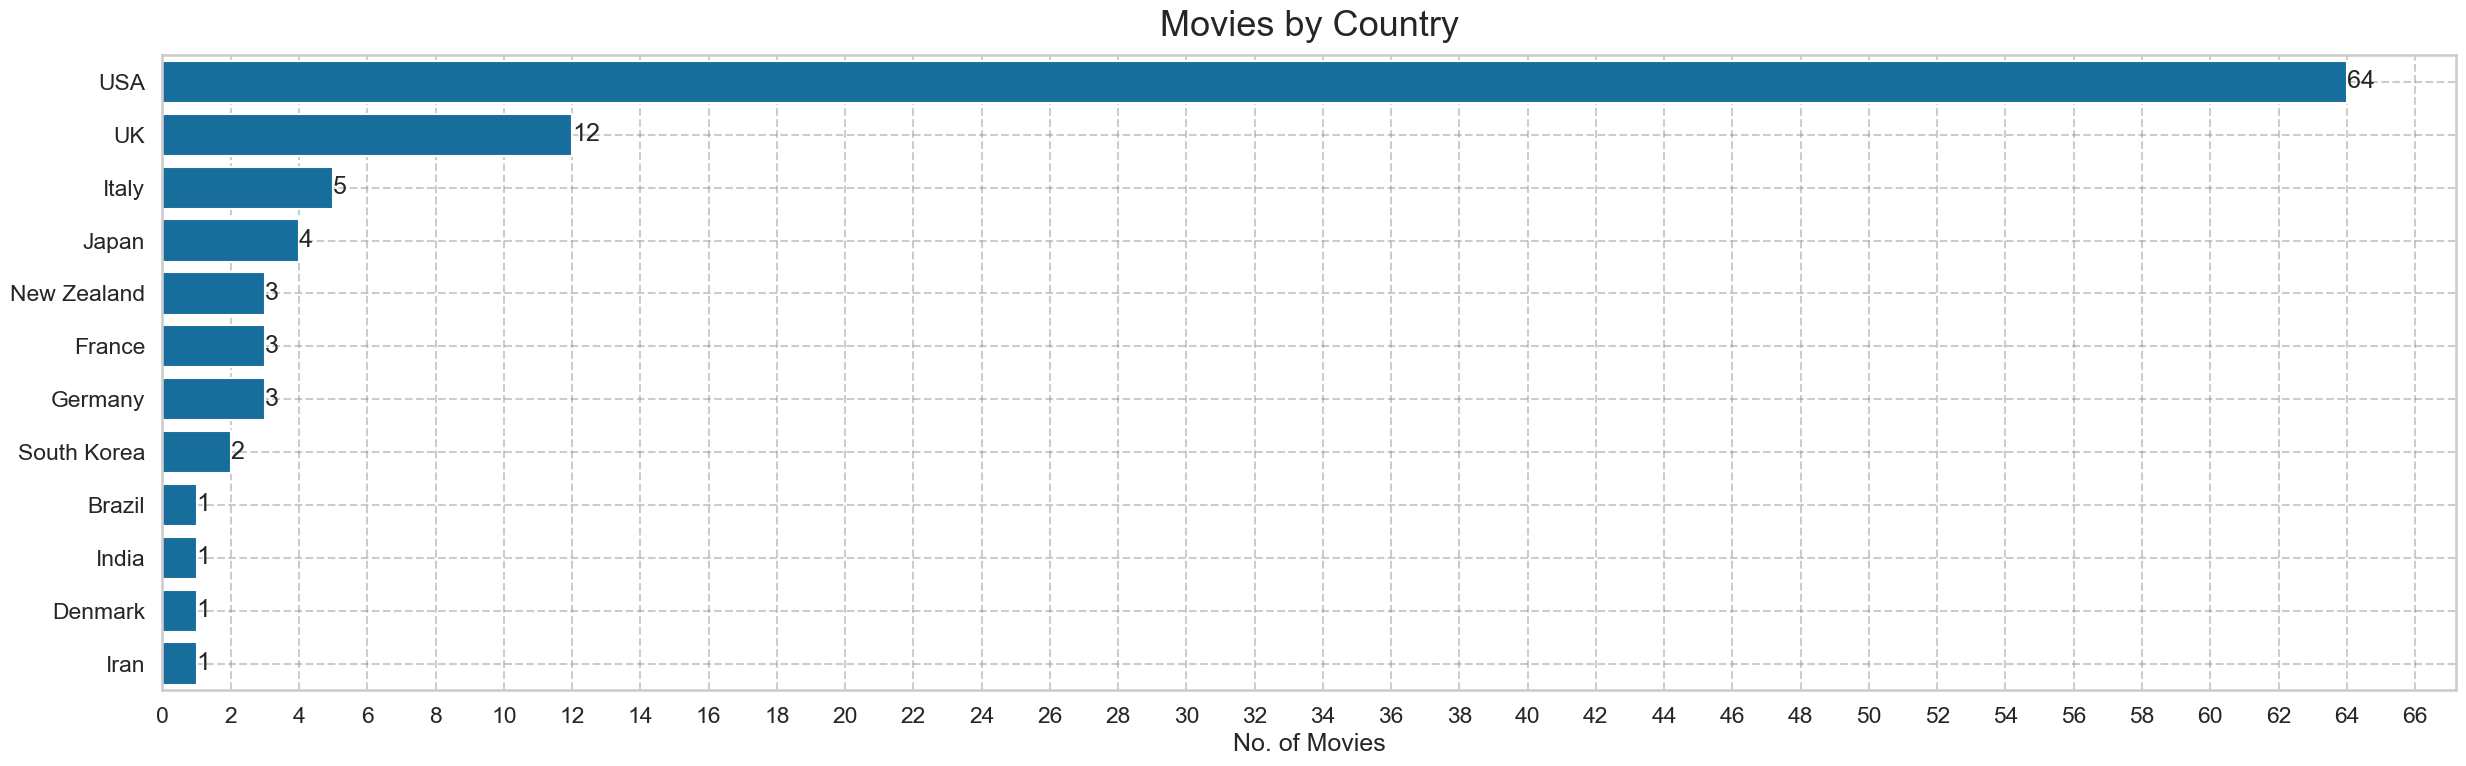

In [5]:
plt.figure(figsize=(25,8))
sns.set_theme(style = 'whitegrid', context = 'talk', palette='colorblind')
ax = sns.countplot(data=df, y='country', order=order_con)
plt.title("Movies by Country", fontsize=26, pad=14)
plt.grid(True, linestyle='--', alpha=0.4, color='gray')
plt.locator_params(axis='x', nbins=40)
ax.bar_label(ax.containers[0])
plt.ylabel(""); plt.xlabel("No. of Movies")
plt.tight_layout()
plt.savefig('figures/movies_by__country', dpi = 150, bbox_inches = 'tight')
plt.show()
plt.close()

In [6]:
df['content_rating'].value_counts()
order_rat = df['content_rating'].value_counts().index

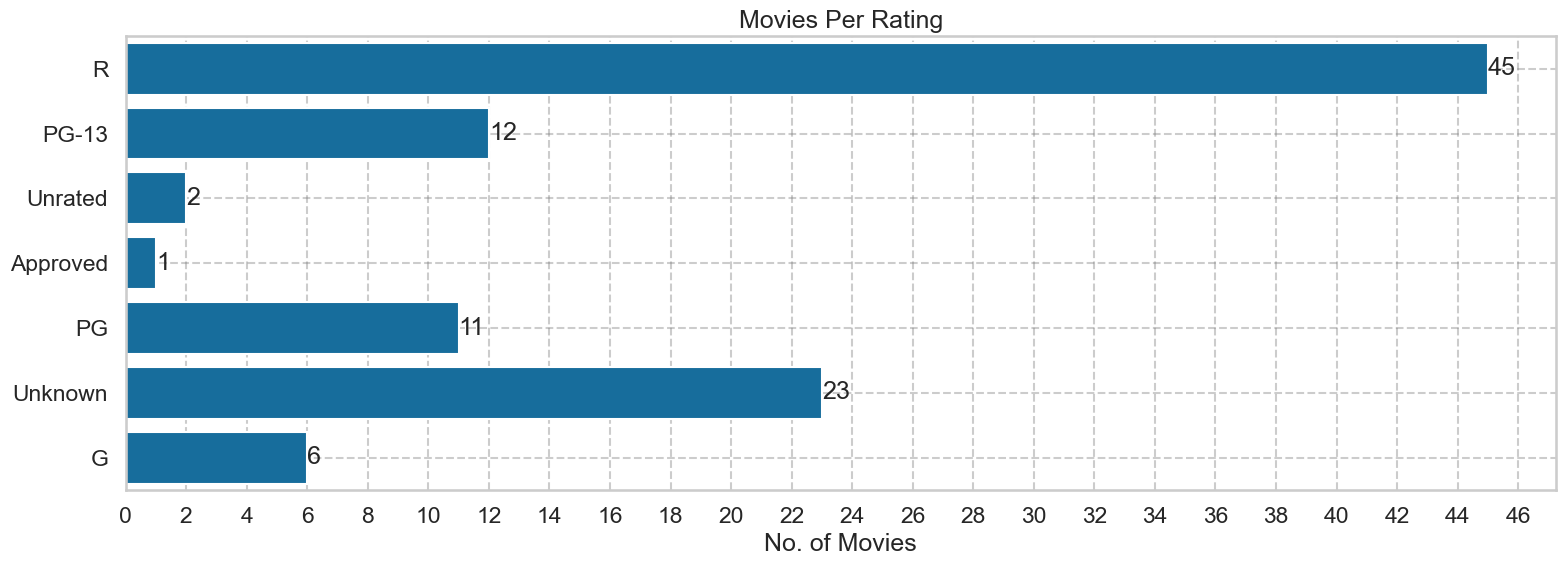

In [7]:
plt.figure(figsize=(16,6))
sns.set_theme(style = 'whitegrid', context = 'talk', palette='colorblind')
ax = sns.countplot(data = df, y='content_rating')
plt.title("Movies Per Rating")
plt.locator_params(axis='x', nbins=30)
ax.grid(True, linestyle='--', alpha=0.4, color='gray')
ax.set_ylabel(""); plt.xlabel('No. of Movies')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.savefig('figures/movies_per_rating', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


In [8]:
df_dir = df['director'].value_counts()
df_10 = df_dir.head(10)
df_other = pd.Series({'Other Directors': df_dir[10:].sum()})
df_com = pd.concat([df_10, df_other])
order_dir = df['director'].value_counts().head()

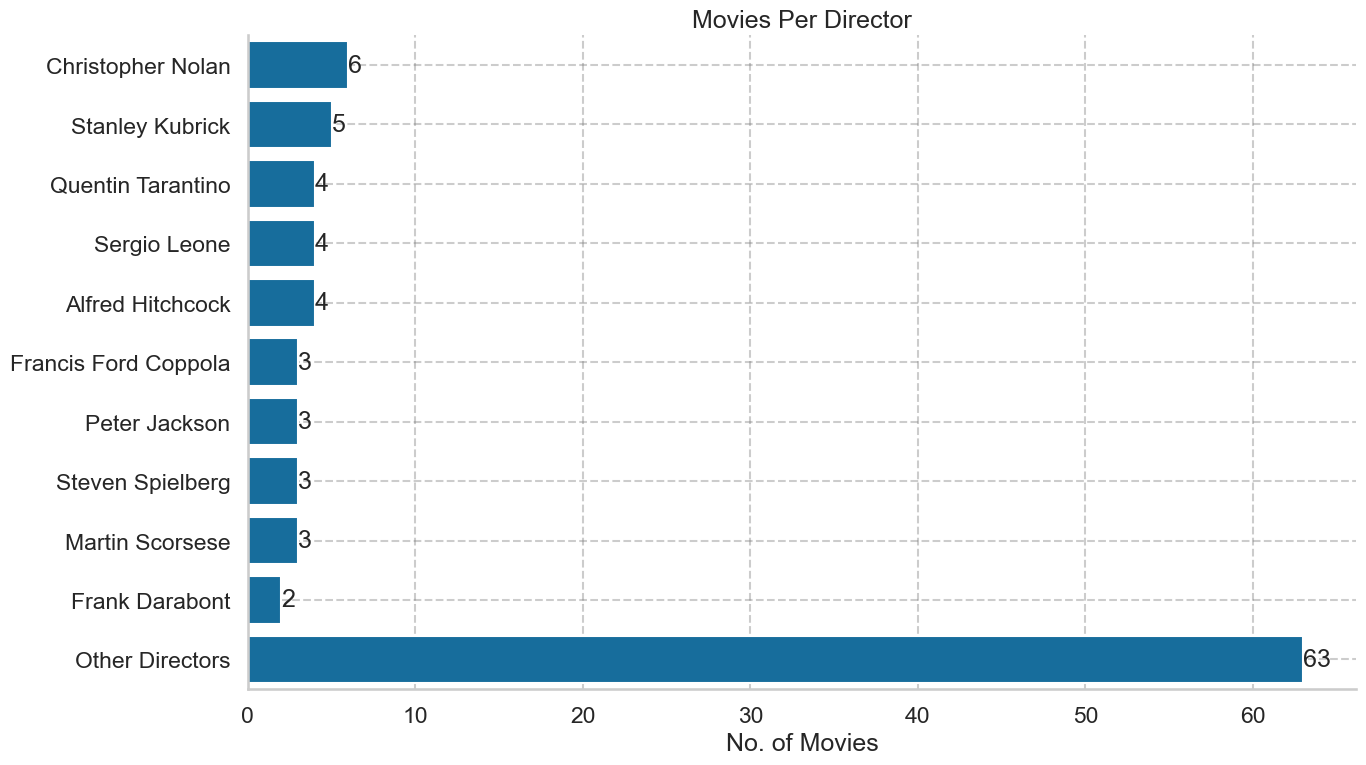

In [9]:
plt.figure(figsize=(14, 8))
sns.set_theme(style = 'whitegrid', context = 'talk', palette='colorblind')
ax = sns.barplot(x = df_com.values, y = df_com.index)
plt.title("Movies Per Director")
plt.locator_params(axis = 'x', nbins=10)
ax.grid(True, linestyle='--', alpha = 0.4, color='gray')
ax.set_ylabel(""); ax.set_xlabel("No. of Movies")
ax.bar_label(ax.containers[0])
plt.tight_layout()
sns.despine()
plt.savefig('figures/movies_per_director', dpi=150, bbox_inches = 'tight')
plt.show()
plt.close()


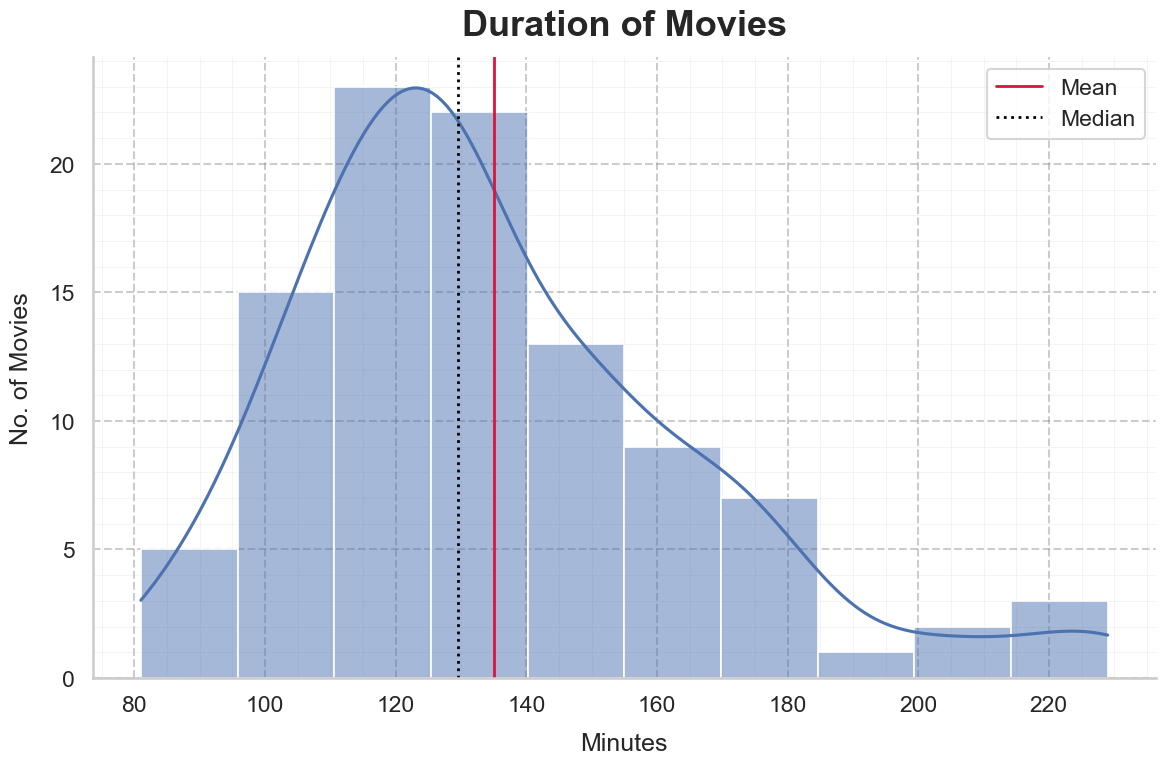

In [10]:
plt.figure(figsize=(12,8))
sns.set_theme(style='whitegrid', context = 'talk', palette='colorblind')
ax = sns.histplot(data=df , x = 'duration', binwidth=15, kde=True, kde_kws={'bw_adjust': 0.8}, edgecolor='white', color='#4C72B0', linewidth=1.2)
ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.grid(which='minor',axis='x', alpha=0.25, linewidth=0.6)
ax.grid(which='minor', axis='y', alpha=0.25, linewidth=0.6)
ax.grid(True, linestyle = '--', alpha=0.4, color='gray')
plt.title('Duration of Movies', fontweight='bold', pad=16, fontsize = 26)
plt.xlabel('Minutes', labelpad=12); plt.ylabel('No. of Movies', labelpad=12)
ax.axvline(df['duration'].mean(), color ='crimson', linestyle='-', linewidth=2, label = 'Mean')
ax.axvline(df['duration'].median(), color='black', linestyle = ':', linewidth=2, label = 'Median')
ax.legend()
plt.tight_layout()
sns.despine()
plt.savefig('figures/duration_of_movies', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


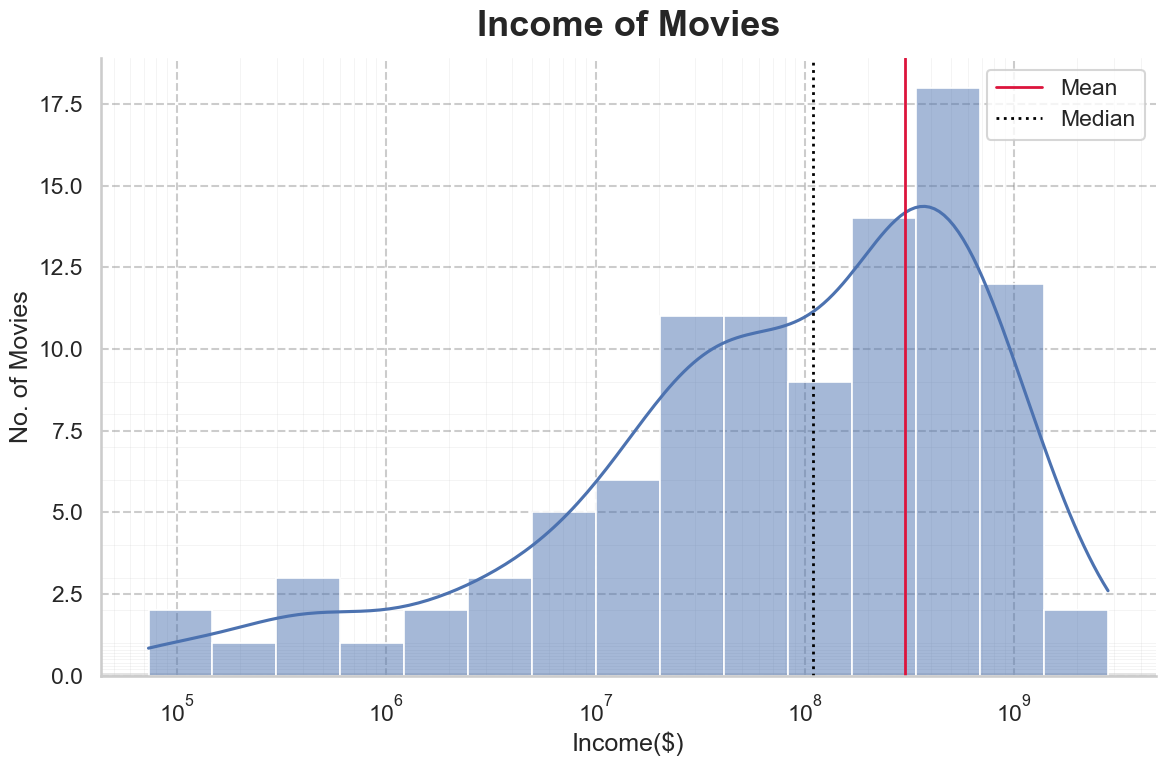

In [11]:
plt.figure(figsize=(12,8))
sns.set_theme(style='whitegrid', context = 'talk', palette='colorblind')
ax = sns.histplot(data=df, x='income', kde=True,bins=15, kde_kws={'bw_adjust': 0.8}, edgecolor='white', color='#4C72B0', linewidth=1.2, log_scale=True)
ax.xaxis.set_minor_locator(mticker.LogLocator(base=10, subs='all'))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs='all'))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.grid(which='minor', axis='x', alpha=0.25, linewidth=0.6)
ax.grid(which='minor', axis='y', alpha=0.25, linewidth=0.6)
ax.grid(True, linestyle='--', alpha=0.4, color = 'gray')
plt.title("Income of Movies", fontweight='bold', pad=16, fontsize=26)
plt.xlabel('Income($)'); plt.ylabel('No. of Movies')
ax.axvline(df['income'].mean(), color='crimson', linestyle='-', linewidth=2, label='Mean')
ax.axvline(df['income'].median(), color='black', linestyle=':', linewidth=2, label='Median')
ax.legend()
plt.tight_layout()
sns.despine()
plt.savefig('figures/income_of_movies', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

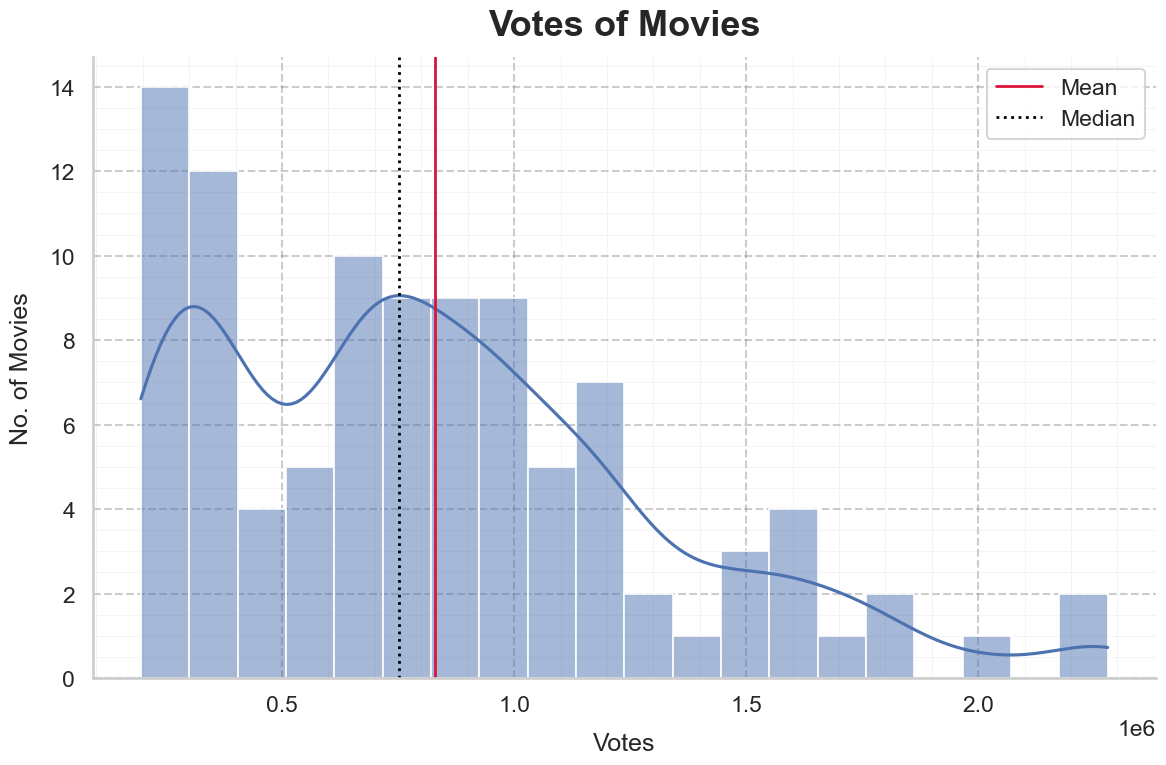

In [12]:
plt.figure(figsize=(12,8))
sns.set_theme(style='whitegrid', context = 'talk', palette='colorblind')
ax = sns.histplot(data=df, x='votes',bins=20, kde=True, kde_kws={'bw_adjust':0.6}, edgecolor='white', color='#4C72B0', linewidth=1.2)
ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.grid(which='minor', axis='x', alpha=0.25, linewidth=0.6)
ax.grid(which='minor', axis='y', alpha=0.25,linewidth=0.6)
ax.grid(True, linestyle='--', alpha=0.4, color='gray')
plt.title("Votes of Movies", fontweight='bold', fontsize=26, pad=16)
plt.xlabel("Votes", labelpad=12);plt.ylabel('No. of Movies', labelpad=12)
ax.axvline(df['votes'].mean(), color='crimson', linestyle='-', linewidth=2, label='Mean')
ax.axvline(df['votes'].median(), color='black', linestyle=':', linewidth=2, label='Median')
ax.legend()
plt.tight_layout()
sns.despine()
plt.savefig('figures/votes_of_moves', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

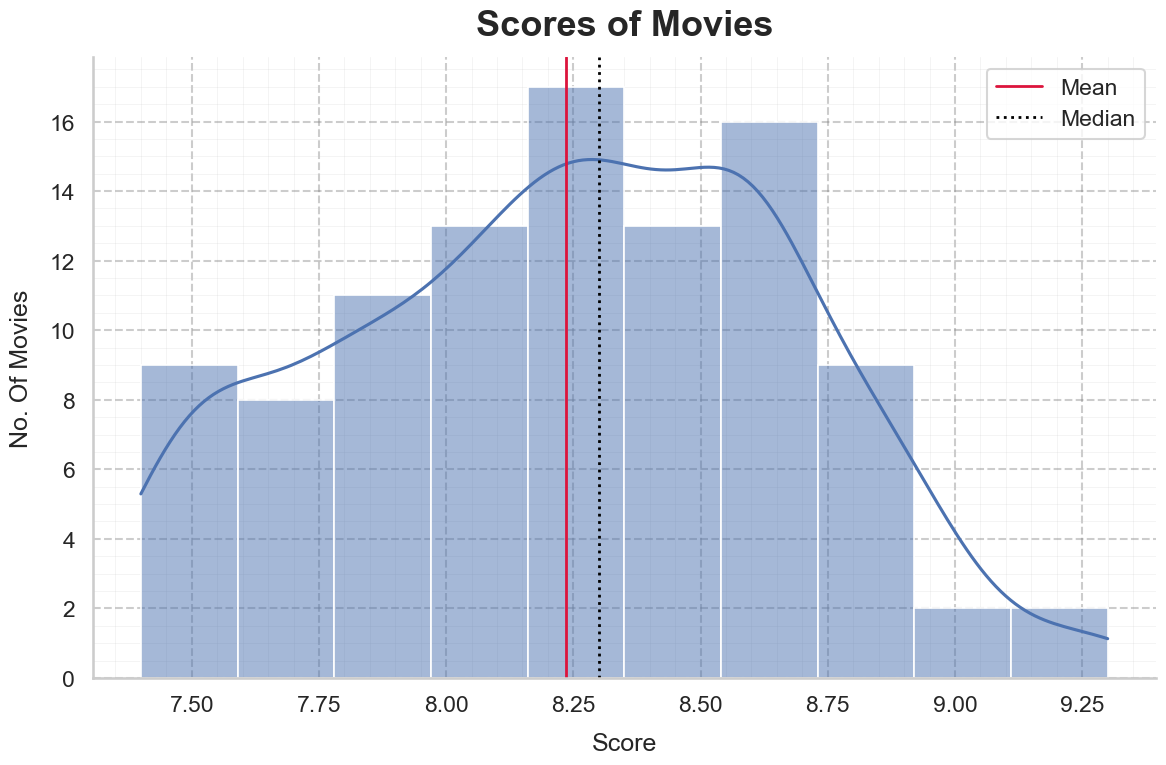

In [13]:
plt.figure(figsize=(12,8))
sns.set_theme(style='whitegrid', context='talk', palette='colorblind')
ax=sns.histplot(data=df, x='score', binwidth=0.2, kde=True, kde_kws={'bw_adjust':0.7}, edgecolor='white', color='#4C72B0', linewidth=1.2)
ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.grid(which='minor', axis='x', alpha=0.25, linewidth=0.6)
ax.grid(which='minor', axis='y', alpha=0.25,linewidth=0.6)
ax.grid(True, linestyle='--', alpha=0.4, color='gray')
plt.title('Scores of Movies', fontweight='bold', fontsize=26, pad=16)
plt.xlabel("Score", labelpad=12);plt.ylabel('No. Of Movies', labelpad=12)
ax.axvline(df['score'].mean(), color='crimson', linestyle='-', linewidth=2, label='Mean')
ax.axvline(df['score'].median(), color='black', linestyle=':', linewidth=2, label='Median')
ax.legend()
plt.tight_layout()
sns.despine()
plt.savefig('figures/scores_of_movies', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

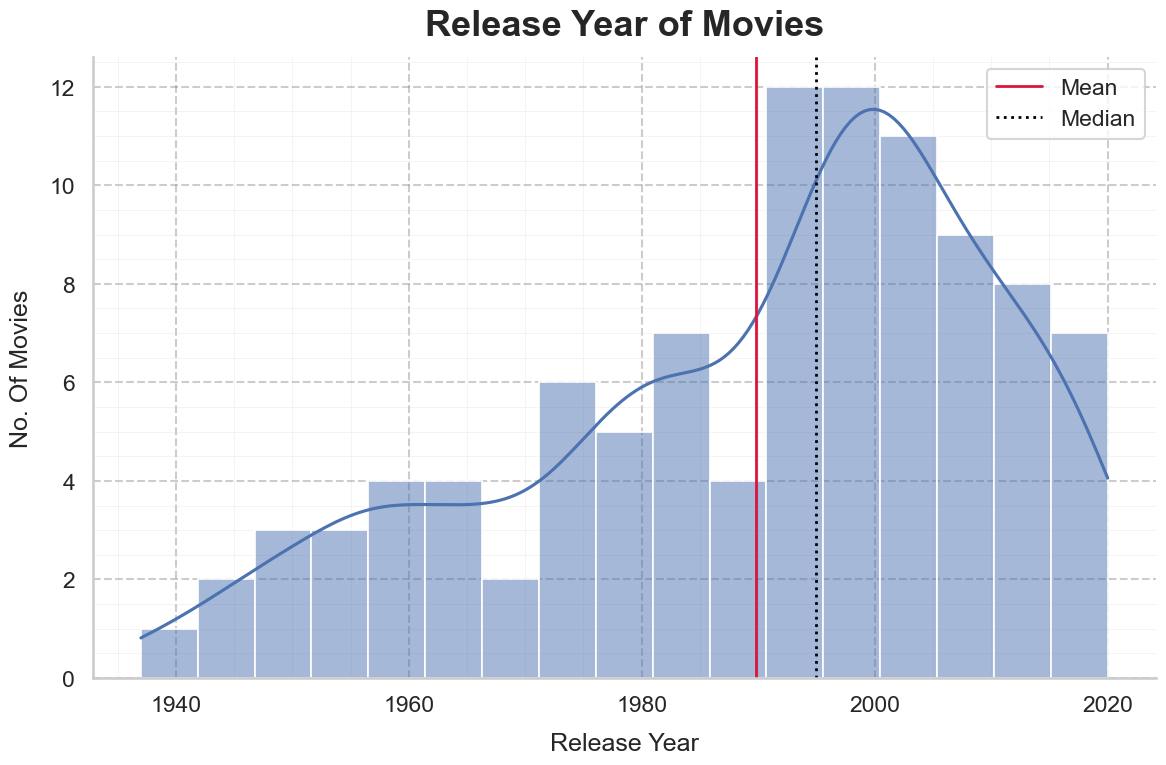

In [14]:
plt.figure(figsize=(12,8))
sns.set_theme(style='whitegrid', context='talk', palette='colorblind')
ax=sns.histplot(data=df, x='year',binwidth=5, kde=True, kde_kws={'bw_adjust':0.6}, edgecolor='white', color='#4C72B0', linewidth=1.2)
ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.grid(which='minor', axis='x', alpha=0.25, linewidth=0.6)
ax.grid(which='minor', axis='y', alpha=0.25,linewidth=0.6)
ax.grid(True, linestyle='--', alpha=0.4, color='gray')
plt.title('Release Year of Movies', fontweight='bold', fontsize=26, pad=16)
plt.xlabel("Release Year", labelpad=12);plt.ylabel('No. Of Movies', labelpad=12)
ax.axvline(df['year'].mean(), color='crimson', linestyle='-', linewidth=2, label='Mean')
ax.axvline(df['year'].median(), color='black', linestyle=':', linewidth=2, label='Median')
ax.legend()
plt.tight_layout()
sns.despine()
plt.savefig('figures/years_of_movies', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [15]:
df_genres = df.copy()
df_genres['genre'] =  df_genres['genre'].str.split(', ')
df_genres = df_genres.explode('genre')
df_genres

,title_id,original_title,genre,duration,country,content_rating,director,income,votes,score,year
0,tt0111161,The Shawshank Redemption,Drama,142.0,USA,R,Frank Darabont,28815245,2278845,9.3,1995
1,tt0068646,The Godfather,Crime,175.0,USA,R,Francis Ford Coppola,246120974,1572674,9.2,1972
1,tt0068646,The Godfather,Drama,175.0,USA,R,Francis Ford Coppola,246120974,1572674,9.2,1972
2,tt0468569,The Dark Knight,Action,152.0,USA,PG-13,Christopher Nolan,1005455211,2241615,9.0,2008
2,tt0468569,The Dark Knight,Crime,152.0,USA,PG-13,Christopher Nolan,1005455211,2241615,9.0,2008
...,...,...,...,...,...,...,...,...,...,...,...
97,tt0059578,Per qualche dollaro in piÃ¹,Western,132.0,Italy,Unknown,Sergio Leone,15000000,226039,7.4,1965
98,tt1832382,Jodaeiye Nader az Simin,Drama,123.0,Iran,PG-13,Asghar Farhadi,22926076,214165,7.4,2011
99,tt0045152,Singin' in the Rain,Comedy,103.0,USA,Unknown,Stanley Donen,1864182,213152,7.4,1953
99,tt0045152,Singin' in the Rain,Musical,103.0,USA,Unknown,Stanley Donen,1864182,213152,7.4,1953


In [16]:
genres=df_genres['genre'].value_counts()
top_genres = genres.head(10)
rest = genres[10:]
other = pd.Series({f'Other {len(rest)} Genres': rest.sum()})
com_genres=pd.concat([top_genres,other])

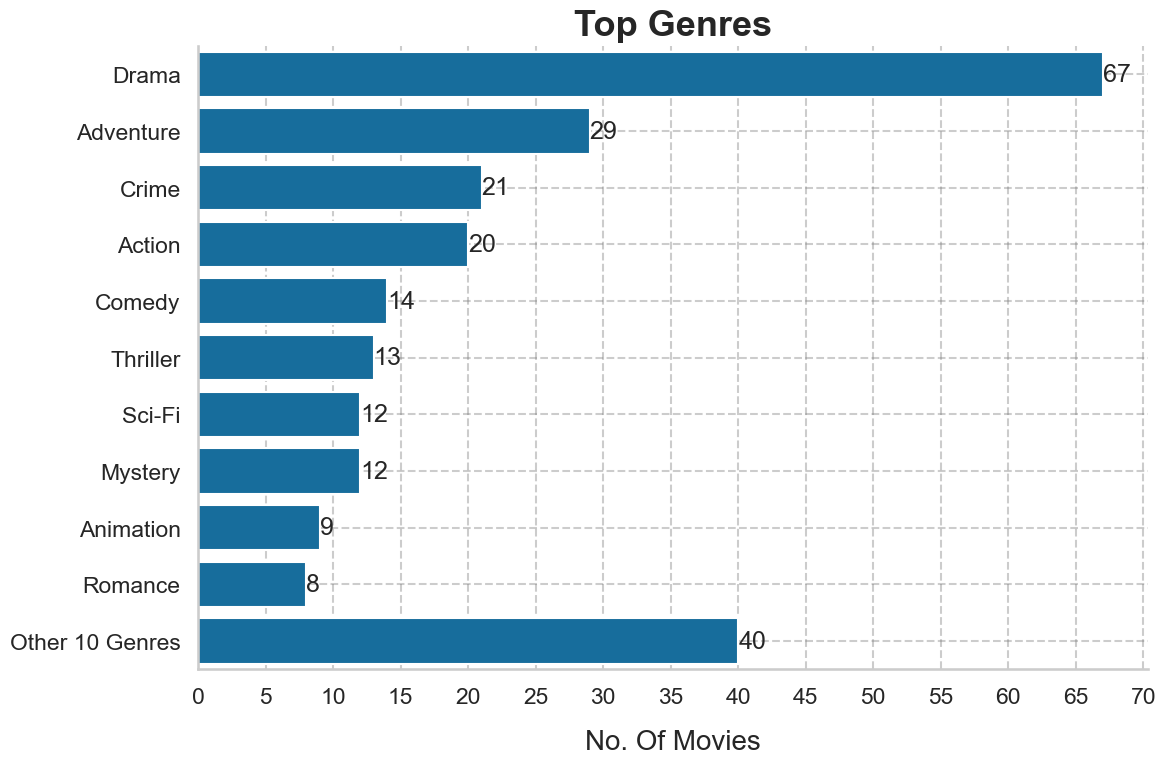

In [17]:
plt.figure(figsize=(12,8))
sns.set_theme(style='whitegrid', context='talk', palette='colorblind')
ax= sns.barplot(y=com_genres.index, x=com_genres.values, )
plt.locator_params(axis='x',nbins=20)
plt.title("Top Genres", fontweight='bold', fontsize=26, pad=8)
plt.ylabel("");plt.xlabel("No. Of Movies", fontsize=20,labelpad=16)
ax.grid(True, linestyle='--', alpha=0.4,color='gray')
ax.bar_label(ax.containers[0])
plt.tight_layout()
sns.despine()
plt.savefig("figures/top_genres",dpi=150,bbox_inches='tight')
plt.show()
plt.close()



### Q.1 How are the numerical columns correlated?
- The heatmap below shows all the correlation coeifficients between the numerical columns
- The Score and Votes columns are the highest correlated
- The Year and Duration columns are the lowest correlated

<Axes: >

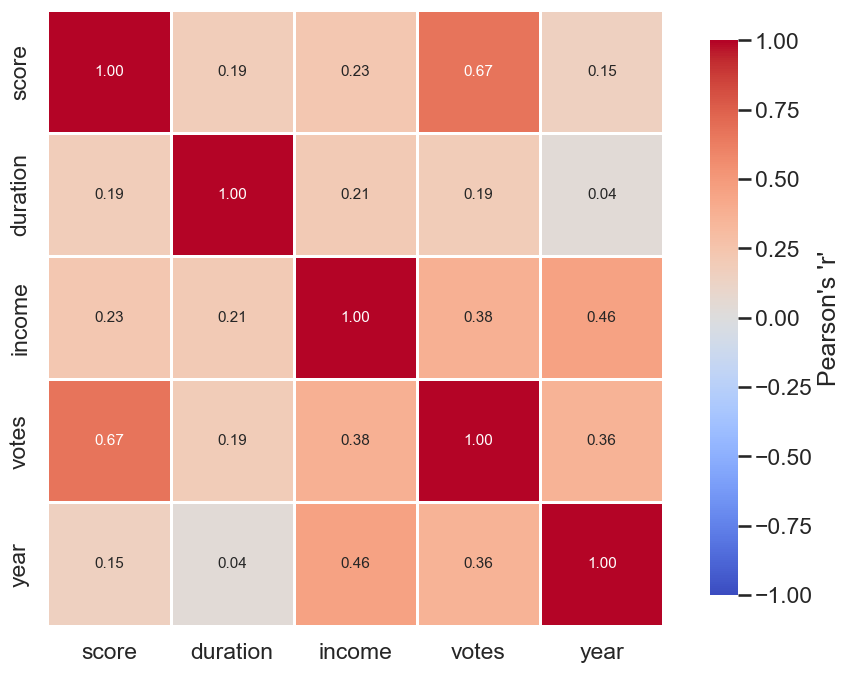

In [18]:
corr = df[['score', 'duration', 'income', 'votes', 'year']].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1,vmax=1, square=True, linewidths=1, linecolor='white', cbar_kws={'label':"Pearson's 'r'", 'shrink':0.9,}, annot_kws={'size':11})

### Q.2 Do Longer Movies Get Better Scores?
- The Duration and Score columns show a weak positive correlation with score r=0.19 but the scores do lie in a very narrow band of between 7.4 and 9.3
- There are only a 100 movies in this database so it might now be enough
- The scatterplot shows 3 outliers with movies that have incredbily long runtimes

In [19]:
print(f"The Duration and Score attributes are {df['score'].corr(df['duration']) * 100:.2f}% correlated")

The Duration and Score attributes are 18.74% correlated


In [20]:
df['Region'] = np.where(df['country']=='USA', 'US', 'Non-US')

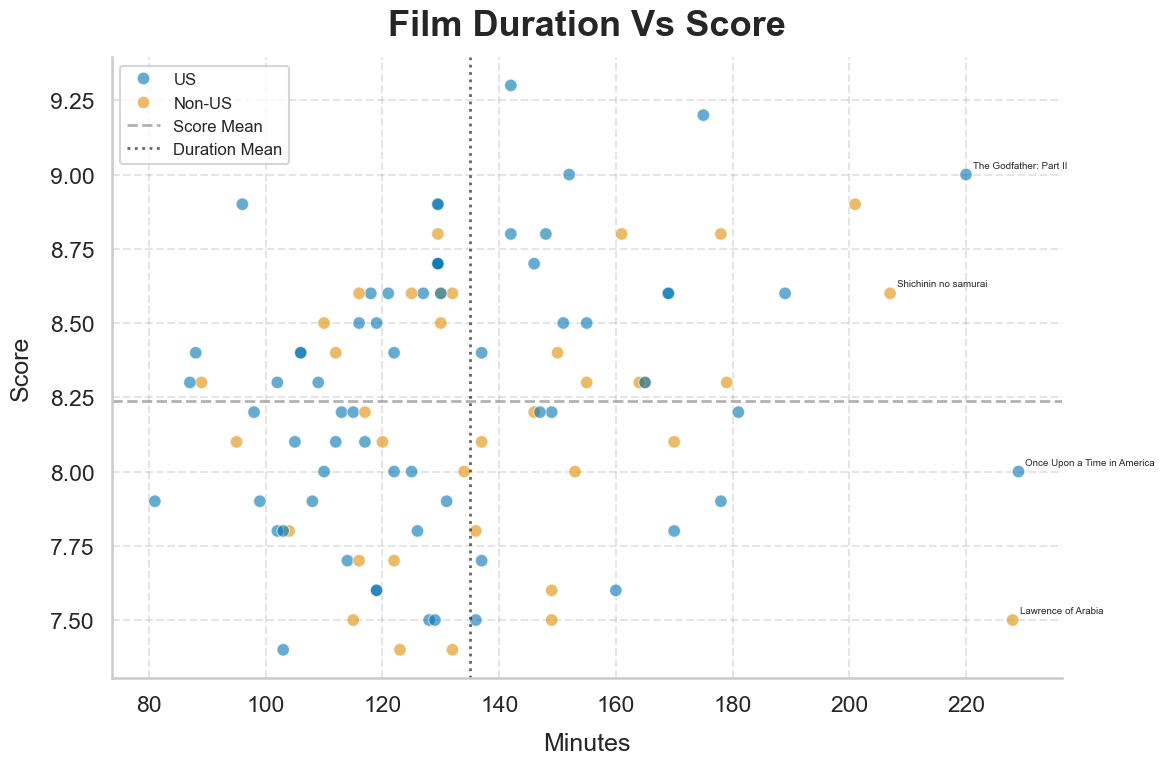

In [21]:
plt.figure(figsize=(12,8))
ax = sns.scatterplot(data=df, x='duration', y='score',alpha=0.6, color='#4C72B0', edgecolor='white', linewidth=0.8, hue='Region')
for _, r in df.nlargest(4, 'duration').iterrows():
    ax.annotate(r['original_title'], (r['duration'], r['score']), xytext=(5,5), textcoords='offset points', fontsize=7)
ax.grid(True, linestyle='--', alpha=0.2, color='gray')
plt.title('Film Duration Vs Score', fontweight='bold', fontsize=26, pad=16)
plt.xlabel("Minutes", labelpad=12);plt.ylabel("Score", labelpad=12)
ax.axhline(df['score'].mean(), color='gray', linestyle='--', linewidth=2, alpha=0.6, label='Score Mean')
ax.axvline(df['duration'].mean(), color='black', linestyle=':', linewidth=2, alpha=0.6, label='Duration Mean')
ax.legend(fontsize=12)
plt.savefig('figures/filmduration_vs_score', dpi=150, bbox_inches='tight')
plt.tight_layout()
sns.despine()
plt.show()

<Axes: xlabel='duration', ylabel='score'>

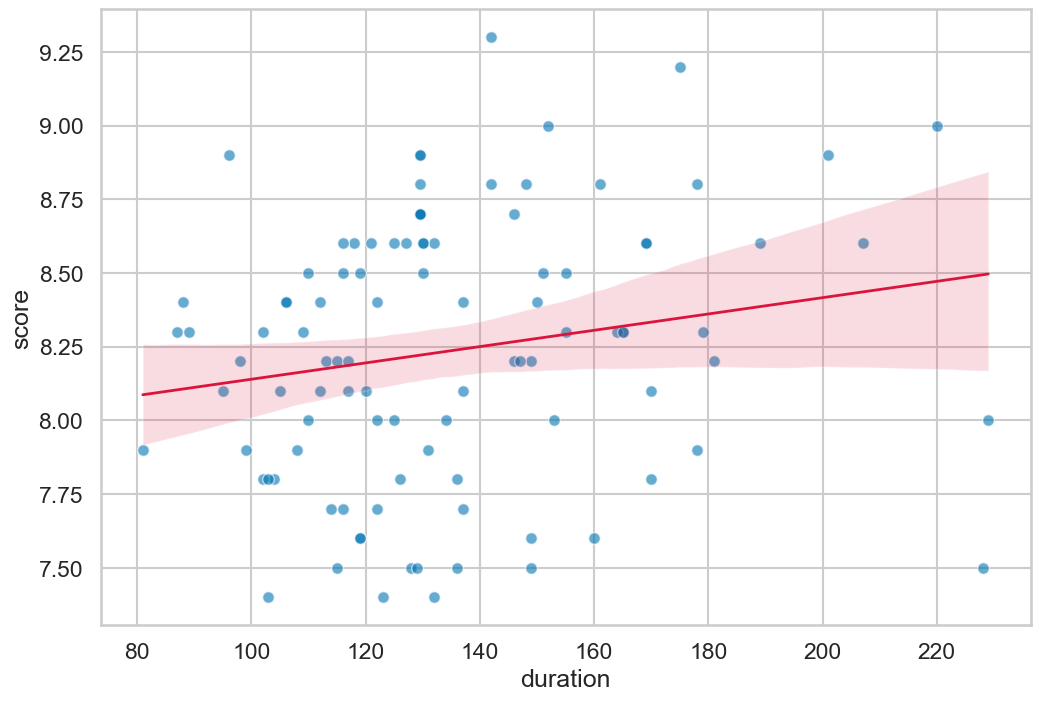

In [22]:
plt.figure(figsize=(12,8))
sns.regplot(data=df, x='duration', y='score', scatter_kws={'alpha':0.6, 's':70, 'edgecolor':'white'}, line_kws={'color':'crimson','linewidth':2}, ci=95)

In [23]:
dq1=df['duration'].quantile(0.25)
dq3=df['duration'].quantile(0.75)
iqr = dq3-dq1
lower = dq1 - (1.5*iqr)
upper = dq3 + (1.5*iqr)
mask = (df['duration']<lower)|(df['duration']>upper)
df[mask]['original_title']
for film in df[mask]['original_title']:
    print(f"The film {film} is an outlier with a runtime that is very long/small.")


The film The Godfather: Part II is an outlier with a runtime that is very long/small.
The film Shichinin no samurai is an outlier with a runtime that is very long/small.
The film Once Upon a Time in America is an outlier with a runtime that is very long/small.
The film Lawrence of Arabia is an outlier with a runtime that is very long/small.


### Q3. Does popularity track quality — do vote counts and scores agree?
The Votes and Score attributes have a strong positive correlation with r = 0.67.
This can be attributed to the fact that users who like a movie more are more likely to give it a rating or it means that films with more votes appear higher up on the IMDB list and are more visible
The Shawshank Redemption and Dark Knight are outliers in terms of vote counts

In [24]:
print(f"The Votes and Score attributes are r={df['score'].corr(df['votes'])} correlated")

The Votes and Score attributes are r=0.6704932718137906 correlated


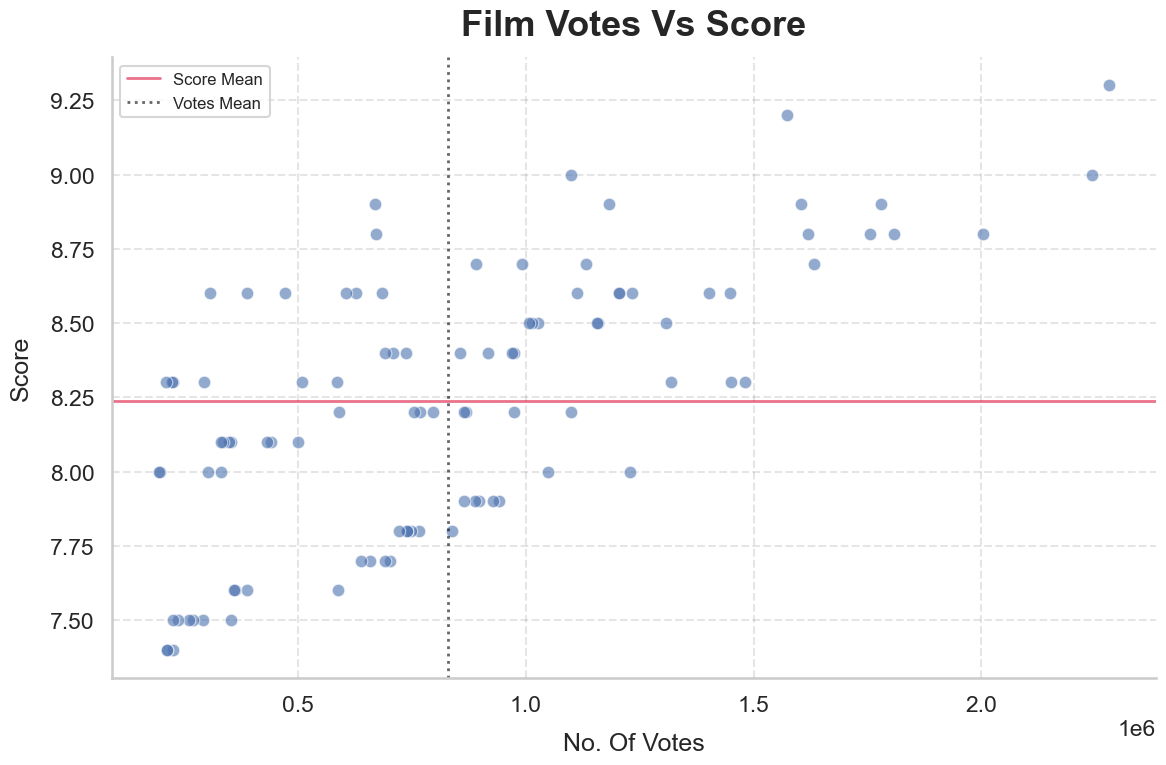

In [25]:
plt.figure(figsize=(12,8))
ax = sns.scatterplot(data=df, x='votes', y='score', alpha = 0.6, edgecolor='white', linewidth=0.8, color='#4C72B0')
ax.grid(True, linestyle='--', color='gray', alpha=0.2)
plt.title("Film Votes Vs Score", fontweight='bold', fontsize=26, pad=16)
plt.xlabel('No. Of Votes', labelpad=12); plt.ylabel("Score", labelpad=12)
ax.axhline(df['score'].mean(), color='crimson', linestyle='-', linewidth=2, alpha=0.6, label="Score Mean")
ax.axvline(df['votes'].mean(), color='black', linestyle=':',linewidth=2, alpha=0.6, label='Votes Mean')
ax.legend(fontsize=12)
plt.tight_layout()
sns.despine()
plt.savefig('figures/votes_vs_score', dpi=150, bbox_inches='tight')
plt.show()

<Axes: xlabel='votes', ylabel='score'>

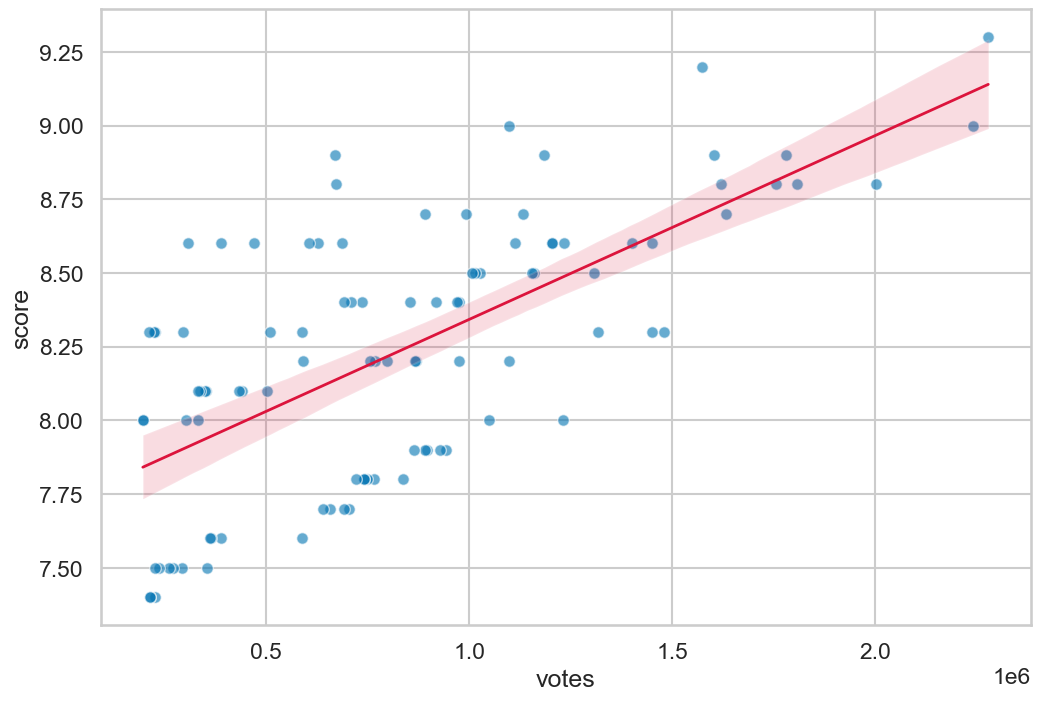

In [26]:
plt.figure(figsize=(12,8))
sns.regplot(data=df, x='votes', y='score', scatter_kws={'alpha':0.6, 's':70, 'edgecolor':'white'}, line_kws={'color':'crimson', 'linewidth':2}, ci=95)

In [27]:
vq1 = df['votes'].quantile(0.25)
vq3 = df['votes'].quantile(0.75)
iqr = vq3-vq1
lower = vq1 - (1.5*iqr)
upper = vq3 + (1.5*iqr)
mask = (df['votes']<lower)|(df['votes']>upper)

if df[mask]['original_title'].empty:
    print('There are no outliers')
else:
    for film in df[mask]['original_title']:
        print(f"The film {film} is an outlier with a large/small amount of votes")

The film The Shawshank Redemption is an outlier with a large/small amount of votes
The film The Dark Knight is an outlier with a large/small amount of votes


Q1. Do longer films score higher?
Tools: corr, scatter + regression line (sns.regplot). Why it's good: a plausible folk belief ("epics are prestige films") that the data can refute. Watch for: correlation ≠ causation, and check whether one 229-minute outlier drives it.

Q2. Does popularity track quality — do vote counts and scores agree?
Tools: corr, scatter, maybe log-x. Why: this is the strongest relationship in your data, and it has two competing explanations (great films attract voters vs. heavily-voted films climb rankings). Naming both interpretations is what makes it analysis.

Q3. Which decade produced the highest-rated films?
Tools: pd.cut (decade bins), groupby + agg(['mean','count']), bar or line. Why: nostalgia is testable. Watch for: your 1930s decade has one film — an average of one movie isn't a decade's quality. Report counts alongside means, always.

Q4. Which genres score best, and which earn most — do the two rankings agree?
Tools: exploded genre frame, groupby().agg(), sort_values, two sorted bars side by side. Why: the tension is the finding — prestige vs. box office is a real industry divide.

Q5. Which genre is most revenue-efficient per minute of runtime?
Tools: derived column (income / duration), explode, groupby, sorted bar. Why: forces you to create a metric rather than read one — the step where analysis becomes original.

Q6. Do repeat directors outperform one-film directors?
Tools: value_counts → isin/map to flag repeats, boolean masking, grouped comparison, box plot. Why: exercises masking, and tests a real hypothesis about auteurs. Watch for: sample sizes, and whether "repeat" here just means "famous enough to make the list twice."

Q7. How do score and income vary across content rating and decade?
Tools: pivot_table (rows=rating, cols=decade, values=score), heatmap. Why: your only genuinely two-dimensional question, and it's what pivot tables exist for. Watch for: sparse cells, and that 23-film "Unknown" bucket.

Q8. Has the average film gotten longer, richer, or better over time?
Tools: groupby decade + agg on three columns, line chart(s). Why: trend questions are what stakeholders actually ask. Watch for: the dual-axis trap — runtime in minutes and income in dollars must not share a y-axis. Two charts or small multiples.

### Q4. Which decade produced the highest-rated films?
- The 1990s had the highest average score for the films produced in that decade and it also had the second highest number films of all the decades so it's a defendible answer.
- The 1930s and 2020s had an average score of 8.3 and 7.6 respectively but they only contained one film 

In [28]:
df['decades']= pd.cut(df['year'], bins=[1930,1940,1950,1960,1970,1980,1990,2000,2010,2020,2030] ,labels =["1930s","1940s","1950s","1960s","1970s","1980s","1990s","2000s","2010s","2020s"], right=False)

In [29]:
dec_df = df.groupby('decades')['score'].agg({'mean','count','median'})
dec_df['mean'] = round(dec_df['mean'],2)

C:\Users\PC\AppData\Local\Temp\ipykernel_62192\1124036100.py:7: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  plt.locator_params(axis = 'x', nbins=10)


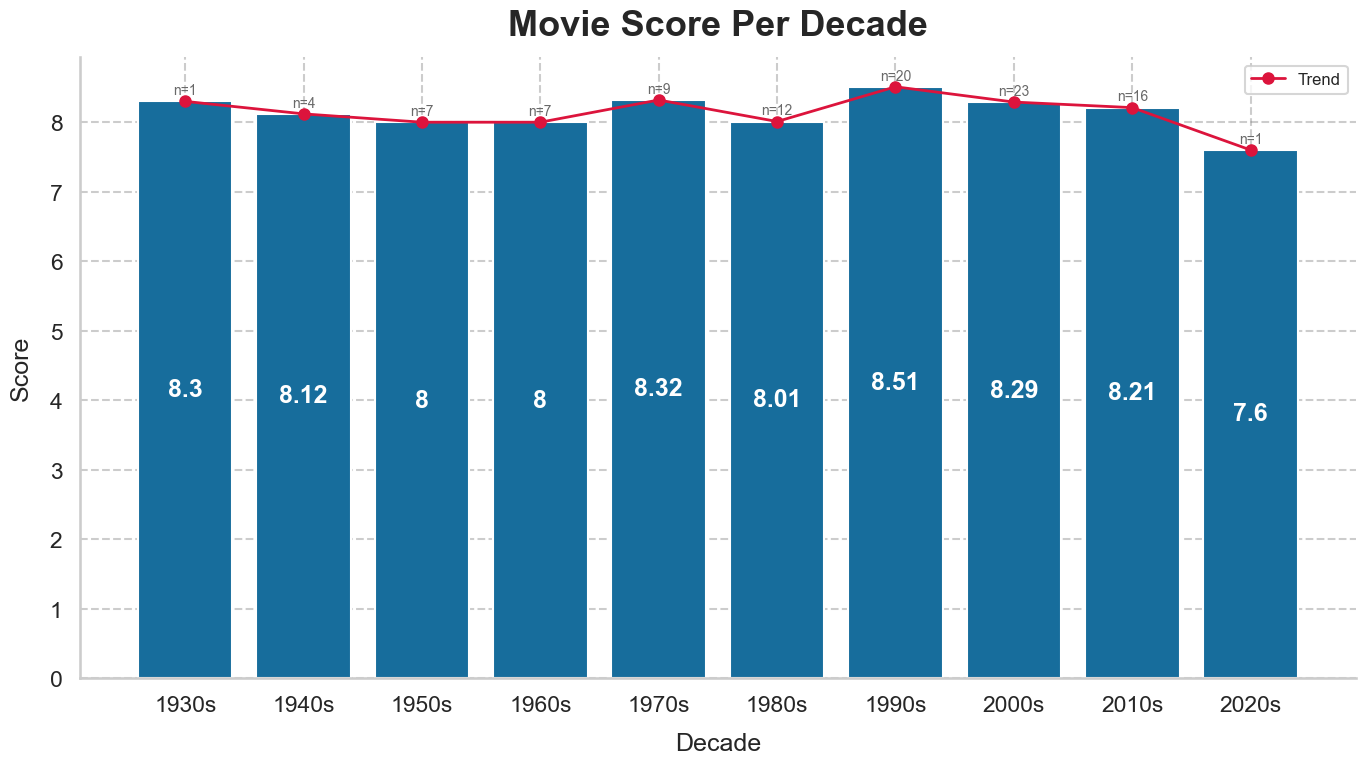

In [30]:
plt.figure(figsize=(14, 8))
sns.set_theme(style = 'whitegrid', context = 'talk', palette='colorblind')
ax = sns.barplot(x = dec_df.index, y = dec_df['mean'])
ax.plot(range(len(dec_df)), dec_df['mean'], color='crimson', marker='o', markersize=8, linewidth=2, zorder=5, label='Trend')
ax.legend(fontsize=12)
plt.title("Movie Score Per Decade", fontweight='bold', fontsize=26, pad=16)
plt.locator_params(axis = 'x', nbins=10)
ax.grid(True, linestyle='--', alpha = 0.4, color='gray')
ax.set_ylabel("Score", labelpad=12); ax.set_xlabel("Decade", labelpad=12)
ax.bar_label(ax.containers[0], labels=[f"n={c}" for c in dec_df['count']], padding = 3, fontsize=10, color='dimgray', label_type='edge')
ax.bar_label(ax.containers[0], label_type='center', color='white', fontweight='bold')
plt.tight_layout()
sns.despine()
plt.savefig('figures/moviescore_per_decade', dpi=150, bbox_inches = 'tight')
plt.show()
plt.close()


### Q5. Which genres score best, and which earn most — do the two rankings agree?
- Action scored the highest and it is also the genre that had the highest income
- Suprisngly, animation was the third highest scoring genre but the 8th highest earning
- Sci-Fi and Fantasy appear in the top 5 of both scenarios
- Adventure has the 6th highest score but is the second most earning
- Crime is the 8th most earning genre yet its the 3rd highest rated

In [31]:
genre_count = df_genres.groupby('genre')['score'].count()
mask = genre_count[genre_count>5].index
filt_genre = df_genres[df_genres['genre'].isin(mask)]


In [32]:
score_gen = filt_genre.groupby('genre')['score'].agg(['mean','count'])
score_gen = score_gen.sort_values('mean', ascending = False)
score_gen['mean'] = round(score_gen['mean'],2)

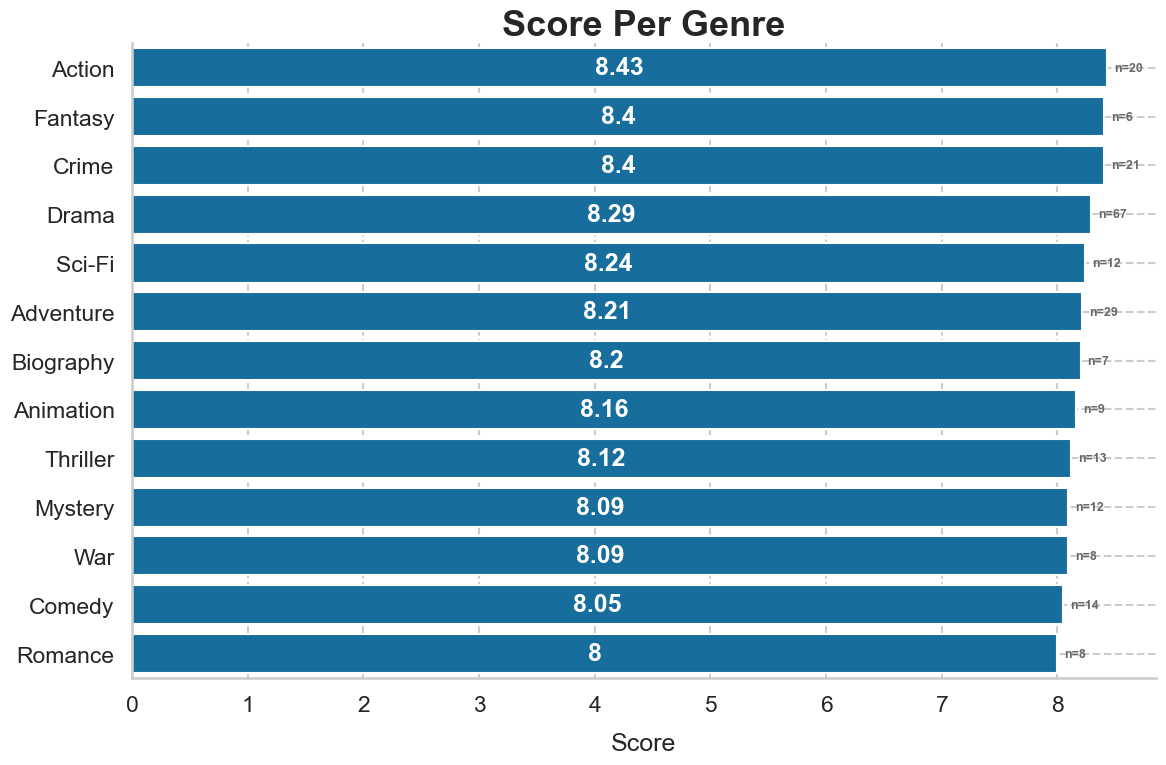

In [33]:
plt.figure(figsize=(12,8))
ax = sns.barplot(y = score_gen.index, x=score_gen['mean'])
plt.title("Score Per Genre", fontweight='bold', fontsize=26)
ax.grid(True, linestyle='--', color='gray', alpha=0.4)
plt.ylabel("");plt.xlabel("Score", labelpad=12)
ax.bar_label(ax.containers[0], labels=(f"n={c}" for c in score_gen['count']), padding = 5, fontsize=9, color='dimgray', label_type='edge',fontweight='bold')
ax.bar_label(ax.containers[0], label_type='center', color='white', fontweight='bold')
plt.tight_layout()
sns.despine()
plt.savefig("figures/scores_per_genre", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [34]:
income_gen = filt_genre.groupby('genre')['income'].agg(['mean','count'])
income_gen = income_gen.sort_values('mean', ascending=False)
income_gen['mean'] = round(income_gen['mean'],0)

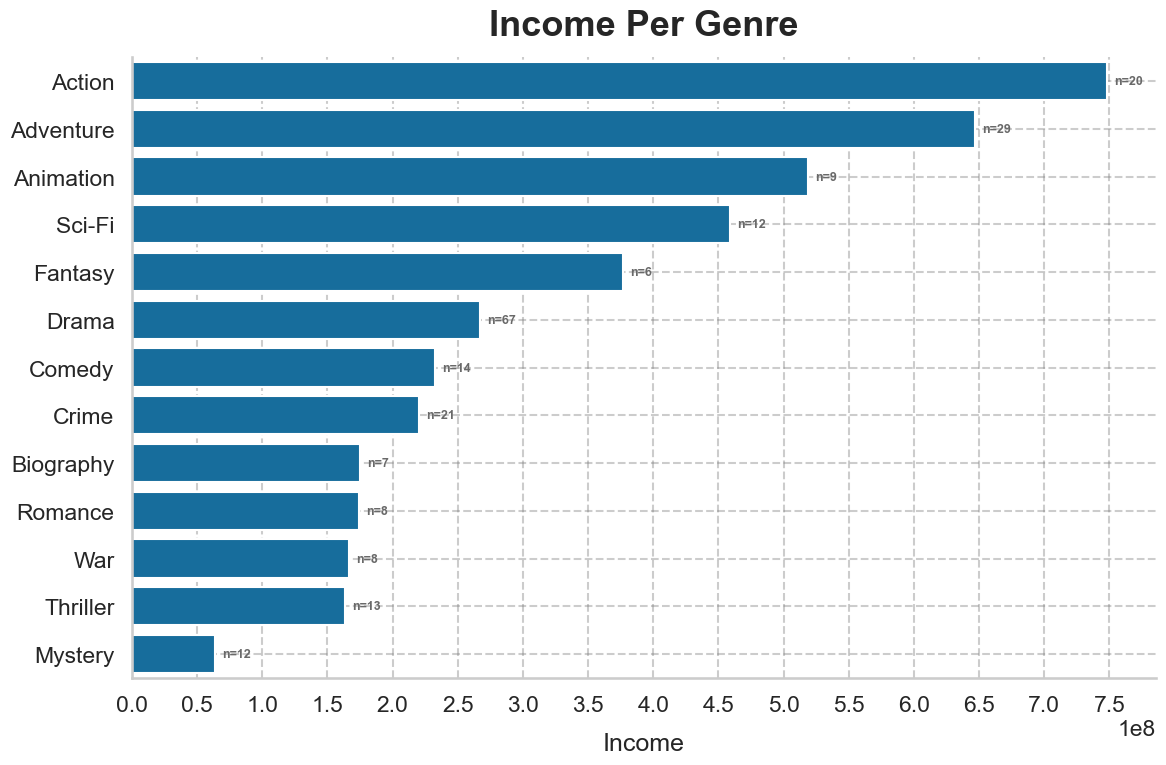

In [35]:
plt.figure(figsize=(12,8))
ax = sns.barplot(y = income_gen.index, x=income_gen['mean'])
plt.title("Income Per Genre", fontweight='bold', fontsize=26, pad= 16)
plt.locator_params(axis='x',nbins=20)
ax.grid(True, linestyle='--', color='gray', alpha=0.4)
plt.ylabel("");plt.xlabel("Income", labelpad=12)
ax.bar_label(ax.containers[0], labels=(f"n={c}" for c in income_gen['count']), padding = 5, fontsize=9, color='dimgray', label_type='edge',fontweight='bold')
plt.tight_layout()
sns.despine()
plt.savefig("figures/scores_per_genre", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### Q6. Which genre is most revenue-efficient per minute of runtime?
- Animation, Action and Adventure had are the most revenue efficient per minute of runtime by far

In [36]:
df_genres['per_min'] = round(df_genres['income']/df_genres['duration'],2)
df_genres

,title_id,original_title,genre,duration,country,content_rating,director,income,votes,score,year,per_min
0,tt0111161,The Shawshank Redemption,Drama,142.0,USA,R,Frank Darabont,28815245,2278845,9.3,1995,202924.26
1,tt0068646,The Godfather,Crime,175.0,USA,R,Francis Ford Coppola,246120974,1572674,9.2,1972,1406405.57
1,tt0068646,The Godfather,Drama,175.0,USA,R,Francis Ford Coppola,246120974,1572674,9.2,1972,1406405.57
2,tt0468569,The Dark Knight,Action,152.0,USA,PG-13,Christopher Nolan,1005455211,2241615,9.0,2008,6614836.91
2,tt0468569,The Dark Knight,Crime,152.0,USA,PG-13,Christopher Nolan,1005455211,2241615,9.0,2008,6614836.91
...,...,...,...,...,...,...,...,...,...,...,...,...
97,tt0059578,Per qualche dollaro in piÃ¹,Western,132.0,Italy,Unknown,Sergio Leone,15000000,226039,7.4,1965,113636.36
98,tt1832382,Jodaeiye Nader az Simin,Drama,123.0,Iran,PG-13,Asghar Farhadi,22926076,214165,7.4,2011,186390.86
99,tt0045152,Singin' in the Rain,Comedy,103.0,USA,Unknown,Stanley Donen,1864182,213152,7.4,1953,18098.85
99,tt0045152,Singin' in the Rain,Musical,103.0,USA,Unknown,Stanley Donen,1864182,213152,7.4,1953,18098.85


In [37]:
genres = df_genres.groupby('genre')['score'].count()
mask = genres[genres>5].index
filt_genres=df_genres[df_genres['genre'].isin(mask)]
filt_genres

,title_id,original_title,genre,duration,country,content_rating,director,income,votes,score,year,per_min
0,tt0111161,The Shawshank Redemption,Drama,142.0,USA,R,Frank Darabont,28815245,2278845,9.3,1995,202924.26
1,tt0068646,The Godfather,Crime,175.0,USA,R,Francis Ford Coppola,246120974,1572674,9.2,1972,1406405.57
1,tt0068646,The Godfather,Drama,175.0,USA,R,Francis Ford Coppola,246120974,1572674,9.2,1972,1406405.57
2,tt0468569,The Dark Knight,Action,152.0,USA,PG-13,Christopher Nolan,1005455211,2241615,9.0,2008,6614836.91
2,tt0468569,The Dark Knight,Crime,152.0,USA,PG-13,Christopher Nolan,1005455211,2241615,9.0,2008,6614836.91
...,...,...,...,...,...,...,...,...,...,...,...,...
96,tt0082096,Das Boot,Drama,149.0,Germany,R,Wolfgang Petersen,11487676,226427,7.5,1982,77098.50
96,tt0082096,Das Boot,Thriller,149.0,Germany,R,Wolfgang Petersen,11487676,226427,7.5,1982,77098.50
98,tt1832382,Jodaeiye Nader az Simin,Drama,123.0,Iran,PG-13,Asghar Farhadi,22926076,214165,7.4,2011,186390.86
99,tt0045152,Singin' in the Rain,Comedy,103.0,USA,Unknown,Stanley Donen,1864182,213152,7.4,1953,18098.85


In [38]:
rev_min = filt_genres.groupby('genre')['per_min'].agg(['mean','count'])
rev_min['mean'] = round(rev_min['mean'],2)
rev_min = rev_min.sort_values('mean', ascending=False)
rev_min

,mean,count
genre,,
Animation,5187561.00,9
Action,4841096.55,20
Adventure,4699822.51,29
Sci-Fi,3214163.79,12
Fantasy,2852172.26,6
Comedy,2169194.70,14
Drama,1810223.75,67
Crime,1553578.31,21
Romance,1348253.99,8


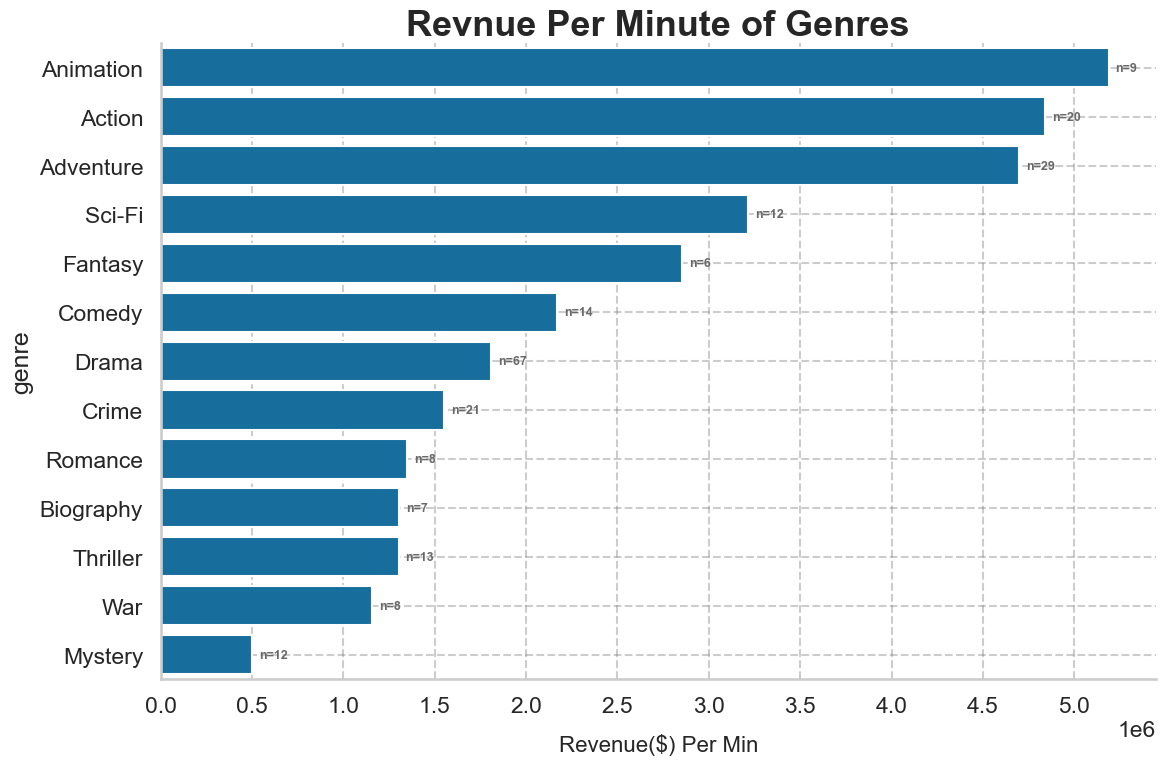

In [39]:
plt.figure(figsize=(12,8))
ax = sns.barplot(x=rev_min['mean'],y=rev_min.index)
plt.title("Revnue Per Minute of Genres", fontweight='bold', fontsize=26)
plt.xlabel("Revenue($) Per Min", fontsize=16, labelpad=12)
plt.locator_params(axis='x', nbins=20)
ax.grid(True, linestyle='--', alpha=0.4, color='gray')
ax.bar_label(ax.containers[0], labels=(f"n={c}" for c in rev_min['count']), padding =5, fontsize=9, color='dimgray', label_type='edge', fontweight='bold')
plt.tight_layout()
sns.despine()
plt.savefig('figures/rev_min_genre', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

### Q7. Do repeat directors outperform one-film directors?
- There were 55 films repeat directors and 45 by one-time directors which is a fairly even split
- Repeat directors scored higher with an 8.3 mean and median compared to the 8.1 mean and median of one-time directors
- Repeat directors scoring higher doesn't neccesarily mean that they had a better directing skill as this is a top 100 list, it could just mean these directors were famous enough that two or more of their films were listed  

In [40]:
rep = df['director'].value_counts()
mask = rep[rep>1].index
df['repeat'] = np.where(df['director'].isin(mask),'Multiple','One')
df

,title_id,original_title,genre,duration,country,content_rating,director,income,votes,score,year,Region,decades,repeat
0,tt0111161,The Shawshank Redemption,Drama,142.0,USA,R,Frank Darabont,28815245,2278845,9.3,1995,US,1990s,Multiple
1,tt0068646,The Godfather,"Crime, Drama",175.0,USA,R,Francis Ford Coppola,246120974,1572674,9.2,1972,US,1970s,Multiple
2,tt0468569,The Dark Knight,"Action, Crime, Drama",152.0,USA,PG-13,Christopher Nolan,1005455211,2241615,9.0,2008,US,2000s,Multiple
3,tt0071562,The Godfather: Part II,"Crime, Drama",220.0,USA,R,Francis Ford Coppola,408035783,1098714,9.0,1975,US,1970s,Multiple
4,tt0110912,Pulp Fiction,"Crime, Drama",129.5,USA,R,Quentin Tarantino,222831817,1780147,8.9,1994,US,1990s,Multiple
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,tt0070735,The Sting,"Comedy, Crime, Drama",129.0,USA,PG,George Roy Hill,156000000,236285,7.5,1974,US,1970s,One
96,tt0082096,Das Boot,"Adventure, Drama, Thriller",149.0,Germany,R,Wolfgang Petersen,11487676,226427,7.5,1982,Non-US,1980s,One
97,tt0059578,Per qualche dollaro in piÃ¹,Western,132.0,Italy,Unknown,Sergio Leone,15000000,226039,7.4,1965,Non-US,1960s,Multiple
98,tt1832382,Jodaeiye Nader az Simin,Drama,123.0,Iran,PG-13,Asghar Farhadi,22926076,214165,7.4,2011,Non-US,2010s,One


In [41]:
df.groupby('repeat')['score'].agg(['mean','median','count'])

,mean,median,count
repeat,,,
Multiple,8.316364,8.3,55
One,8.137778,8.1,45


C:\Users\PC\AppData\Local\Temp\ipykernel_62192\1081794615.py:5: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  plt.locator_params(axis='x', nbins=20)


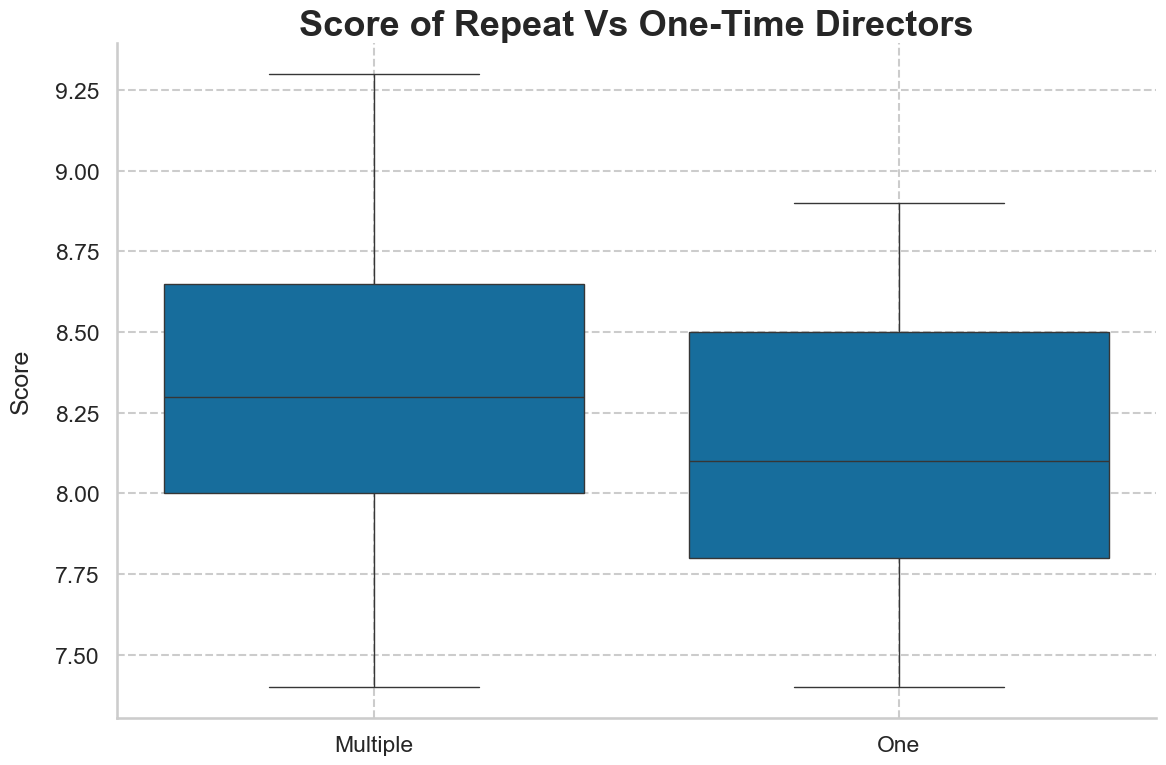

In [42]:
plt.figure(figsize=(12,8))
ax = sns.boxplot(data=df , x='repeat', y='score')
plt.title("Score of Repeat Vs One-Time Directors", fontweight='bold', fontsize=26)
plt.ylabel('Score', labelpad=16),plt.xlabel("")
plt.locator_params(axis='x', nbins=20)
ax.grid(True, linestyle='--', alpha=0.4, color='gray')
plt.tight_layout()
sns.despine()
plt.savefig('figures/rev_min_genre', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


### Q8. How do score and income vary across content rating and decade?
- There are too many missing cells where there are no films corresponding to a Rating and Decade
- There are many cells where there is only one film present and thus it can't be representative of a trend
- No valuable data can be extracted here

In [43]:
score_ratdec = df.pivot_table(values = 'score', index='content_rating',columns='decades', aggfunc=('mean'))
score_ratdec

decades,1930s,1940s,1950s,1960s,1970s,1980s,1990s,2000s,2010s,2020s
content_rating,,,,,,,,,,
Approved,NaN,NaN,NaN,8.8,NaN,NaN,NaN,NaN,NaN,NaN
G,8.3,NaN,NaN,7.6,NaN,NaN,8.150000,8.200000,7.800000,NaN
PG,NaN,8.45,NaN,7.8,8.05,8.325,NaN,8.600000,NaN,NaN
PG-13,NaN,NaN,NaN,8.3,NaN,NaN,8.800000,8.583333,8.275000,NaN
R,NaN,NaN,NaN,8.3,8.50,7.800,8.533333,8.157143,8.066667,NaN
Unknown,NaN,7.80,7.70,7.4,7.80,8.000,8.550000,8.100000,8.287500,7.6
Unrated,NaN,NaN,8.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 92.68333333333327, '')

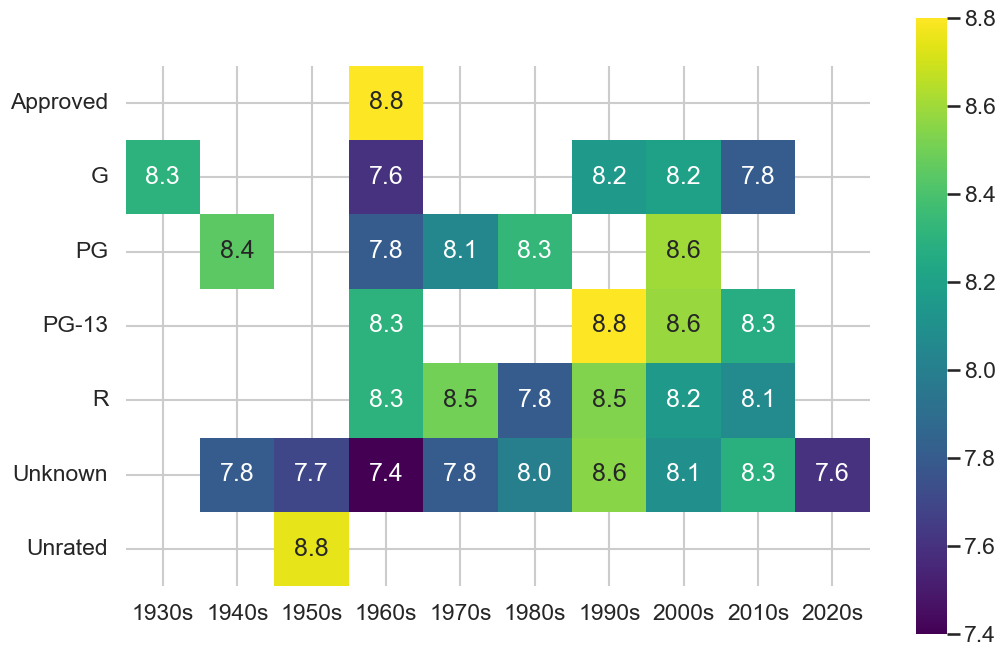

In [44]:
plt.figure(figsize=(12,8))
sns.heatmap(score_ratdec, annot=True, fmt='.1f', cmap='viridis', square=True)
plt.savefig('figures/scoreratdec_heatmap', dpi=150, bbox_inches='tight')
plt.ylabel("");plt.xlabel("")

In [45]:
income_ratdec = df.pivot_table(values = 'income', index='content_rating',columns='decades', aggfunc=('mean'))
income_ratdec

decades,1930s,1940s,1950s,1960s,1970s,1980s,1990s,2000s,2010s,2020s
content_rating,,,,,,,,,,
Approved,NaN,NaN,NaN,25252481.0,NaN,NaN,NaN,NaN,NaN,NaN
G,457688.0,NaN,NaN,68989547.0,NaN,NaN,686388621.5,5.213119e+08,1.066970e+09,NaN
PG,NaN,5252740.5,NaN,27577375.0,4.658845e+08,4.508801e+08,NaN,3.554671e+08,NaN,NaN
PG-13,NaN,NaN,NaN,112911.0,NaN,NaN,678229452.0,7.110583e+08,6.676466e+08,NaN
R,NaN,NaN,NaN,32008644.0,1.652791e+08,5.215937e+07,218688672.2,1.673837e+08,1.633983e+08,NaN
Unknown,NaN,1281993.0,9413139.2,15000000.0,2.690344e+07,3.009214e+07,124825696.0,6.026284e+07,9.734683e+08,384857224.0
Unrated,NaN,NaN,1600264.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Text(0.5, 92.68333333333327, '')

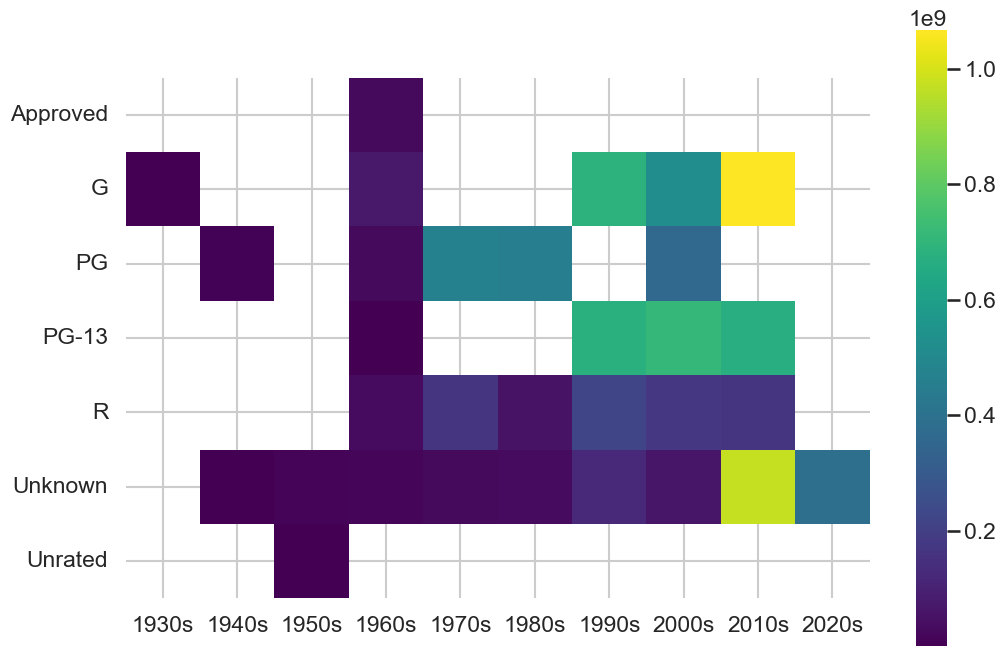

In [46]:
plt.figure(figsize=(12,8))
sns.heatmap(income_ratdec, annot=False, fmt='.1f', cmap='viridis', square=True)
plt.savefig('figures/incomeratdec_heatmap', dpi=150, bbox_inches='tight')
plt.ylabel("");plt.xlabel("")

### Q8. Has the average film gotten longer, richer, or better over time?
Tools: groupby decade + agg on three columns, line chart(s). Why: trend questions are what stakeholders actually ask. Watch for: the dual-axis trap — runtime in minutes and income in dollars must not share a y-axis. Two charts or small multiples.

In [47]:
film_dur = df.groupby('decades')['duration'].agg(['mean'])
film_dur

,mean
decades,
1930s,87.000000
1940s,119.000000
1950s,127.428571
1960s,148.428571
1970s,143.166667
1980s,146.125000
1990s,126.100000
2000s,140.130435
2010s,131.250000


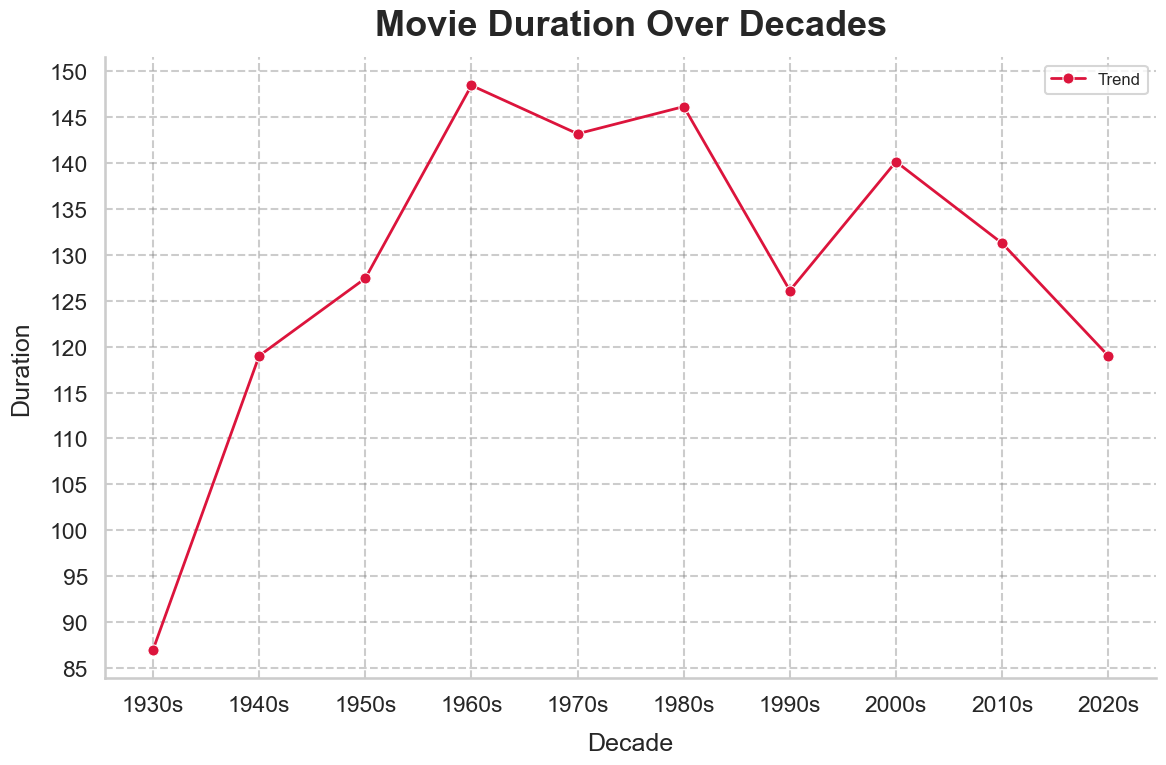

In [48]:
plt.figure(figsize=(12,8))
ax = sns.lineplot(data=film_dur, x='decades', y='mean',color='crimson', marker='o', markersize=8, linewidth=2, zorder=5, label='Trend')
ax.legend(fontsize=12)
plt.title("Movie Duration Over Decades", fontweight='bold', fontsize=26, pad=16)
plt.locator_params(axis = 'y', nbins=20)
ax.grid(True, linestyle='--', alpha = 0.4, color='gray')
ax.set_ylabel("Duration", labelpad=12); ax.set_xlabel("Decade", labelpad=12)
plt.tight_layout()
sns.despine()
plt.savefig('figures/moviedur_over_decade', dpi=150, bbox_inches = 'tight')
plt.show()
plt.close()


In [49]:
film_sco = df.groupby('decades')['score'].agg(['mean'])
film_sco

,mean
decades,
1930s,8.300000
1940s,8.125000
1950s,8.000000
1960s,8.000000
1970s,8.322222
1980s,8.008333
1990s,8.510000
2000s,8.286957
2010s,8.212500


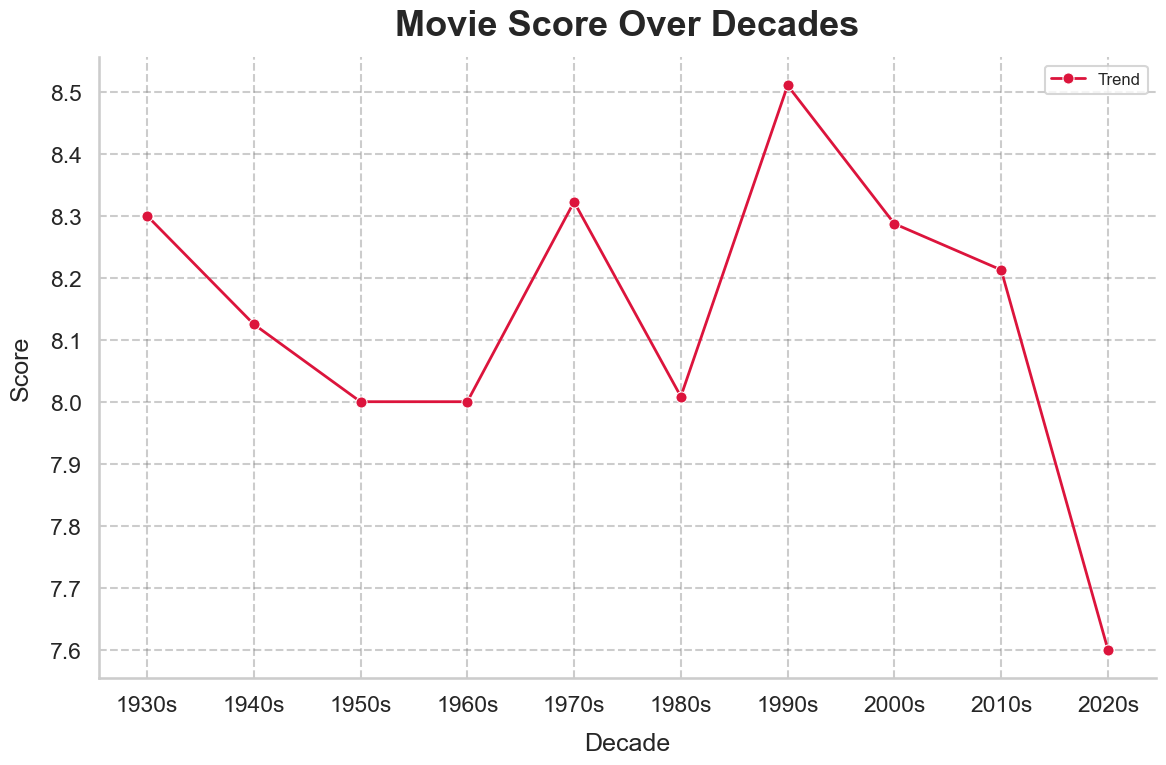

In [50]:
plt.figure(figsize=(12,8))
ax = sns.lineplot(data=film_sco, x='decades', y='mean',color='crimson', marker='o', markersize=8, linewidth=2, zorder=5, label='Trend')
ax.legend(fontsize=12)
plt.title("Movie Score Over Decades", fontweight='bold', fontsize=26, pad=16)
plt.locator_params(axis = 'y', nbins=20)
ax.grid(True, linestyle='--', alpha = 0.4, color='gray')
ax.set_ylabel("Score", labelpad=12); ax.set_xlabel("Decade", labelpad=12)
plt.tight_layout()
sns.despine()
plt.savefig('figures/moviescore_over_decade', dpi=150, bbox_inches = 'tight')
plt.show()
plt.close()

In [51]:
film_inc = df.groupby('decades')['income'].agg(['mean'])
film_inc

,mean
decades,
1930s,4.576880e+05
1940s,3.267367e+06
1950s,7.180889e+06
1960s,2.807405e+07
1970s,2.167052e+08
1980s,1.813884e+08
1990s,2.790494e+08
2000s,3.281202e+08
2010s,7.509686e+08


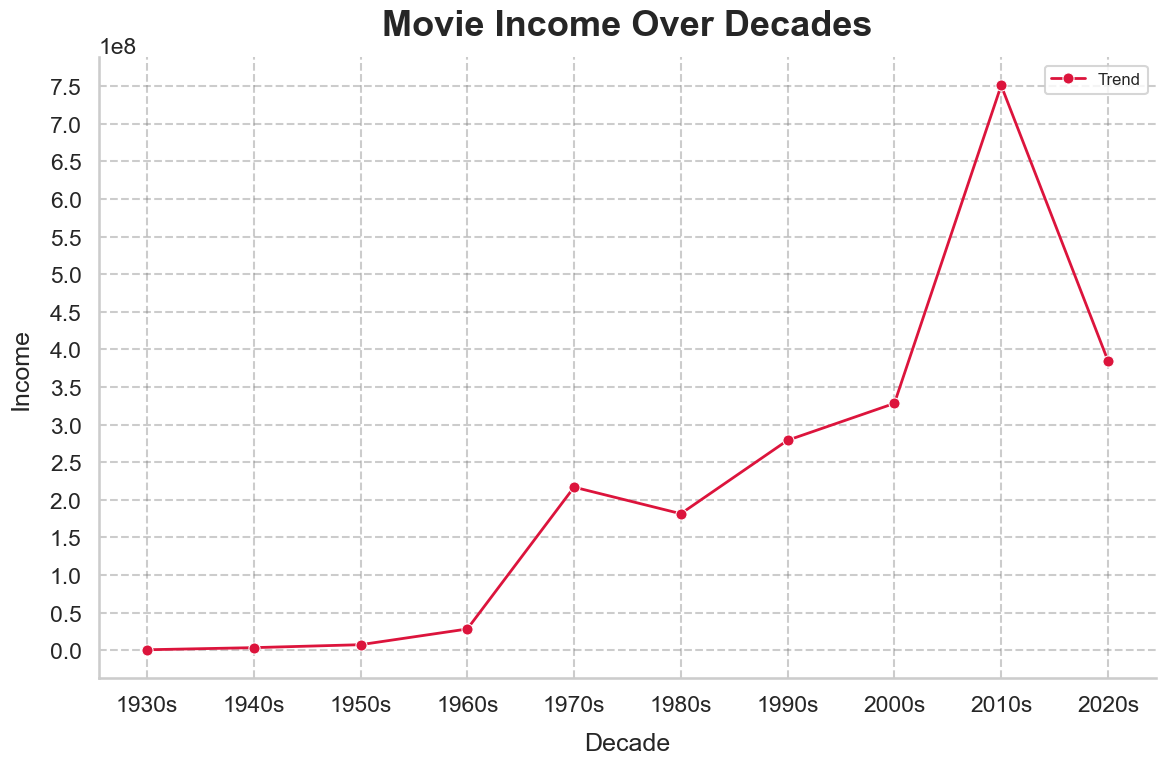

In [53]:
plt.figure(figsize=(12,8))
ax = sns.lineplot(data=film_inc, x='decades', y='mean',color='crimson', marker='o', markersize=8, linewidth=2, zorder=5, label='Trend')
ax.legend(fontsize=12)
plt.title("Movie Income Over Decades", fontweight='bold', fontsize=26, pad=16)
plt.locator_params(axis = 'y', nbins=20)
ax.grid(True, linestyle='--', alpha = 0.4, color='gray')
ax.set_ylabel("Income", labelpad=12); ax.set_xlabel("Decade", labelpad=12)
plt.tight_layout()
sns.despine()
plt.savefig('figures/movieincome_over_decade', dpi=150, bbox_inches = 'tight')
plt.show()
plt.close()